# How the projected shot chart is built, step by step

**Companion notebook to [`src/shot_chart_projection.py`](../src/shot_chart_projection.py)** — that module is
the source of truth (tested, see `tests/test_shot_chart_projection.py`); this notebook re-runs the same
logic in the open to show the court zones, the recency weighting, and the resampling visually.

## The question this answers

The player popup shows a "Proyectado" (projected) shot chart next to the real one. Two things weren't
visible anywhere before this notebook:

1. **How the court gets divided into zones** — this project doesn't invent a zone grid; it uses whatever
   `SHOT_ZONE_BASIC` the NBA's own `ShotChartDetail` endpoint already assigns to every real shot.
2. **How a player's real shots turn into a synthetic projected chart** — the resampling + recency
   weighting + jitter pipeline in `shot_chart_projection.py`, applied here to a real player with real
   cached data.

In [1]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from matplotlib.patches import Arc, Circle, Rectangle

PROJECT_ROOT = Path.cwd().parent
sys.path.insert(0, str(PROJECT_ROOT / "src"))

from shot_chart_projection import project_player_shot_chart, _recency_weighted_shot_pool
from config_loader import load_config
from season_utils import season_start_year

plt.rcParams["figure.facecolor"] = "white"
plt.rcParams["axes.facecolor"] = "white"

config = load_config()
PLAYER_ID = 203954  # Joel Embiid -- the roster player with the longest cached shot history (3 seasons)
PLAYER_NAME = "Joel Embiid"


## 1. The zones are the NBA's, not ours

Every cached real shot in `data/processed/roster_shot_charts.csv` already carries `shot_zone_basic`
(Restricted Area, Mid-Range, Above the Break 3, Corner 3, ...) copied straight from `SHOT_ZONE_BASIC` in the
NBA's own `ShotChartDetail` response (see `data_pipeline.fetch_player_shot_chart`) — computed by the NBA
from the same `LOC_X`/`LOC_Y` coordinates the shot chart displays. This project never draws zone boundaries
or decides where one zone ends and another begins; it just reads the label the API already assigned.
(The raw per-call cache under `data/raw/shot_charts/` isn't committed to this repo — like the rest of
`data/raw/`, it's reproducible from `python src/data_pipeline.py --league-shot-charts` but not shipped — so
this notebook works only from `data/processed/`, which is.)

In [2]:
all_shots_full = pd.read_csv(PROJECT_ROOT / "data" / "processed" / "roster_shot_charts.csv")
raw = all_shots_full[(all_shots_full["player_id"] == PLAYER_ID) & (all_shots_full["season"] == "2025-26")].rename(
    columns={"loc_x": "LOC_X", "loc_y": "LOC_Y", "shot_zone_basic": "SHOT_ZONE_BASIC", "shot_made": "SHOT_MADE_FLAG"}
)
print(f"{len(raw)} real shots 2025-26 season, zone breakdown:")
raw["SHOT_ZONE_BASIC"].value_counts()


697 real shots 2025-26 season, zone breakdown:


SHOT_ZONE_BASIC
Mid-Range                214
Restricted Area          176
Above the Break 3        151
In The Paint (Non-RA)    148
Left Corner 3              5
Right Corner 3             3
Name: count, dtype: int64

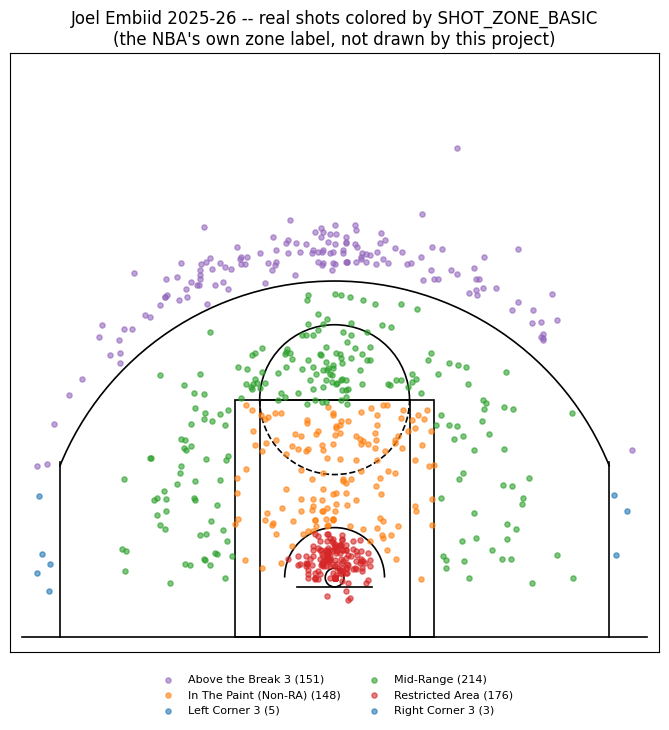

In [3]:
def draw_court(ax, color="black", lw=1.2):
    # Standard NBA half-court, in the same units as LOC_X/LOC_Y (tenths of a foot,
    # hoop at the origin) -- real dimensions, not decorative.
    ax.add_patch(Circle((0, 0), radius=7.5, linewidth=lw, color=color, fill=False))  # hoop
    ax.plot([-30, 30], [-7.5, -7.5], color=color, linewidth=lw)  # backboard
    ax.add_patch(Rectangle((-80, -47.5), 160, 190, linewidth=lw, color=color, fill=False))  # paint (lane)
    ax.add_patch(Rectangle((-60, -47.5), 120, 190, linewidth=lw, color=color, fill=False))  # inner lane
    ax.add_patch(Arc((0, 142.5), 120, 120, theta1=0, theta2=180, linewidth=lw, color=color))  # ft circle top
    ax.add_patch(Arc((0, 142.5), 120, 120, theta1=180, theta2=360, linewidth=lw, color=color, linestyle="dashed"))
    ax.add_patch(Arc((0, 0), 80, 80, theta1=0, theta2=180, linewidth=lw, color=color))  # restricted area
    ax.plot([-220, -220], [-47.5, 92.5], color=color, linewidth=lw)  # corner 3 left
    ax.plot([220, 220], [-47.5, 92.5], color=color, linewidth=lw)  # corner 3 right
    ax.add_patch(Arc((0, 0), 475, 475, theta1=22, theta2=158, linewidth=lw, color=color))  # 3pt arc
    ax.plot([-250, 250], [-47.5, -47.5], color=color, linewidth=lw)  # baseline
    ax.set_xlim(-260, 260)
    ax.set_ylim(-60, 420)
    ax.set_xticks([])
    ax.set_yticks([])
    ax.set_aspect("equal")


ZONE_COLORS = {
    "Restricted Area": "#d62728", "In The Paint (Non-RA)": "#ff7f0e",
    "Mid-Range": "#2ca02c", "Left Corner 3": "#1f77b4", "Right Corner 3": "#1f77b4",
    "Above the Break 3": "#9467bd", "Backcourt": "#7f7f7f",
}

fig, ax = plt.subplots(figsize=(7, 7))
draw_court(ax)
for zone, group in raw.groupby("SHOT_ZONE_BASIC"):
    ax.scatter(group["LOC_X"], group["LOC_Y"], s=14, alpha=0.6, label=f"{zone} ({len(group)})",
               color=ZONE_COLORS.get(zone, "#888"))
ax.legend(loc="upper center", bbox_to_anchor=(0.5, -0.02), ncol=2, fontsize=8, frameon=False)
ax.set_title(f"{PLAYER_NAME} 2025-26 -- real shots colored by SHOT_ZONE_BASIC\n(the NBA's own zone label, not drawn by this project)")
plt.tight_layout()
plt.show()


## 2. How stable is a player's zone mix across seasons?

`shot_chart_projection.py` pools up to `DEFAULT_N_SEASONS_LOOKBACK` (3) seasons, weighting each one by
recency (`0.5 ** (seasons_ago / half_life)`, identical formula to `aging_curve.py`'s per-36 baseline). This
only makes sense if a player's zone mix doesn't reshuffle randomly every year — the investigation behind
this feature measured that directly (mean total-variation distance 0.094 across 11 roster players, 2024-25
vs 2025-26). Here it is for one player, all 3 cached seasons.

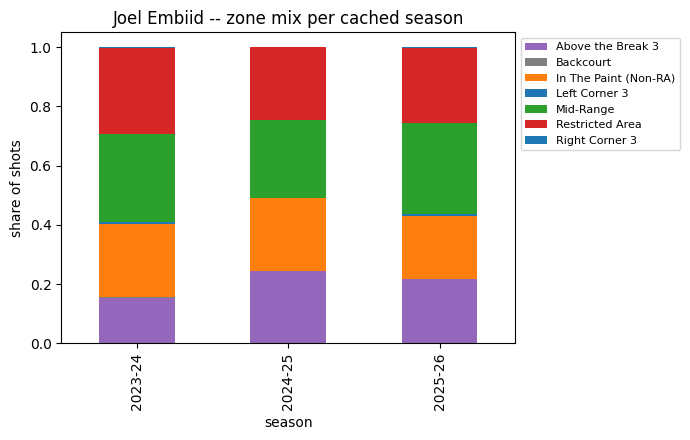

shot_zone_basic,Above the Break 3,Backcourt,In The Paint (Non-RA),Left Corner 3,Mid-Range,Restricted Area,Right Corner 3
season,,,,,,,
2023-24,0.153,0.002,0.248,0.005,0.300,0.289,0.004
2024-25,0.244,0.000,0.244,0.000,0.263,0.248,0.000
2025-26,0.217,0.000,0.212,0.007,0.307,0.253,0.004


In [4]:
all_shots = pd.read_csv(PROJECT_ROOT / "data" / "processed" / "roster_shot_charts.csv")
player_shots = all_shots[all_shots["player_id"] == PLAYER_ID]

zone_share_by_season = (
    player_shots.groupby(["season", "shot_zone_basic"]).size().unstack(fill_value=0)
)
zone_share_by_season = zone_share_by_season.div(zone_share_by_season.sum(axis=1), axis=0)
zone_share_by_season = zone_share_by_season.reindex(
    sorted(zone_share_by_season.index, key=season_start_year)
)

ax = zone_share_by_season.plot(kind="bar", stacked=True, figsize=(7, 4.5),
                                color=[ZONE_COLORS.get(z, "#888") for z in zone_share_by_season.columns])
ax.set_ylabel("share of shots")
ax.set_title(f"{PLAYER_NAME} -- zone mix per cached season")
ax.legend(loc="upper left", bbox_to_anchor=(1.0, 1.0), fontsize=8)
plt.tight_layout()
plt.show()

zone_share_by_season.round(3)


## 3. Recency weighting: what actually goes into the resampling pool

`_recency_weighted_shot_pool` (the same private helper `project_player_shot_chart` calls internally) keeps
the most recent `n_seasons` and assigns each one a weight — the most recent season always gets weight 1.0,
older ones decay by the same half-life formula as the rest of the project.

In [5]:
pool = _recency_weighted_shot_pool(player_shots, n_seasons=3, half_life_seasons=1.5)
pool.groupby("season")["_weight"].first().reindex(sorted(pool["season"].unique(), key=season_start_year, reverse=True))


season
2025-26    1.000000
2024-25    0.629961
2023-24    0.396850
Name: _weight, dtype: float64

## 4. The resampling itself, against this player's real projected totals

`project_player_shot_chart` never decides *how many* shots a player takes next season — that volume
(`FGA_projected`, `FG3A_projected`, `FGM_projected`, `FG3M_projected`) already comes from `aging_curve.py`,
scaled by the same injury-availability factor the rest of the popup uses. This notebook pulls the real
cached projection for this player and feeds it in exactly like `webapp/routers/players.py` does.

In [6]:
projection = pd.read_csv(PROJECT_ROOT / "data" / "processed" / "aging_curve_projection.csv")
row = projection[projection["player_id"] == PLAYER_ID].iloc[0]

injury = pd.read_csv(PROJECT_ROOT / "data" / "processed" / "injury_risk.csv")
risk_score = injury[injury["player_id"] == PLAYER_ID]["risk_score"].iloc[0]
games_per_season = config["simulation"]["games_per_season"]
availability = games_per_season * (1 - risk_score) / games_per_season

target_fga = row["FGA_projected"] * availability
target_fg3a = row["FG3A_projected"] * availability
target_fgm = row["FGM_projected"] * availability
target_fg3m = row["FG3M_projected"] * availability
print(f"risk_score={risk_score:.3f}  availability={availability:.3f}")
print(f"targets -> FGA={target_fga:.1f}  FG3A={target_fg3a:.1f}  FGM={target_fgm:.1f}  FG3M={target_fg3m:.1f}")

projected_shots = project_player_shot_chart(
    player_shots, target_fga, target_fg3a, target_fgm, target_fg3m,
    rng=np.random.default_rng(PLAYER_ID),  # same seed the live endpoint uses -- stable across popup reopens
)

n_3pt = (projected_shots["shot_type"] == "3PT Field Goal").sum()
n_made_3pt = projected_shots[projected_shots["shot_type"] == "3PT Field Goal"]["shot_made"].sum()
n_made_2pt = projected_shots[projected_shots["shot_type"] == "2PT Field Goal"]["shot_made"].sum()
n_made = n_made_3pt + n_made_2pt
print(f"\ngenerated {len(projected_shots)} shots, {n_3pt} of them 3PT, {n_made} marked made")
print(f"exact match to targets: FGA {len(projected_shots) == round(target_fga)}, FG3A {n_3pt == round(target_fg3a)}")
print(f"  2PT makes {n_made_2pt} == round(FGM-FG3M) {round(target_fgm - target_fg3m)}: {n_made_2pt == round(target_fgm - target_fg3m)}")
print(f"  3PT makes {n_made_3pt} == round(FG3M) {round(target_fg3m)}: {n_made_3pt == round(target_fg3m)}")
print(f"  (total makes {n_made} vs round(FGM) {round(target_fgm)} can be off by 1 -- 2PT and 3PT makes"
      f" round independently, this module never rounds the combined FGM as one number)")


risk_score=0.655  availability=0.345
targets -> FGA=425.1  FG3A=91.0  FGM=209.5  FG3M=30.8

generated 425 shots, 91 of them 3PT, 210 marked made
exact match to targets: FGA True, FG3A True
  2PT makes 179 == round(FGM-FG3M) 179: True
  3PT makes 31 == round(FG3M) 31: True
  (total makes 210 vs round(FGM) 209 can be off by 1 -- 2PT and 3PT makes round independently, this module never rounds the combined FGM as one number)


## 5. Real vs. projected, side by side

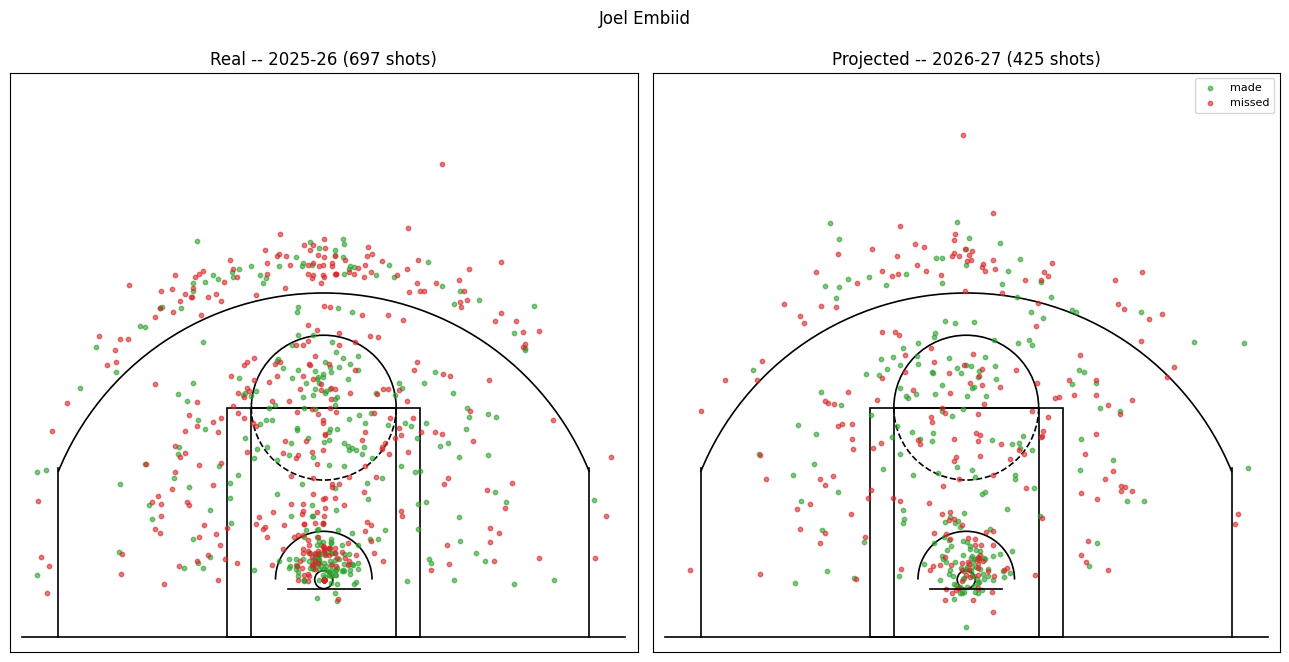

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(13, 7))
for ax, shots, title in (
    (axes[0], player_shots[player_shots["season"] == "2025-26"], f"Real -- 2025-26 ({(player_shots['season']=='2025-26').sum()} shots)"),
    (axes[1], projected_shots, f"Projected -- 2026-27 ({len(projected_shots)} shots)"),
):
    draw_court(ax)
    made = shots[shots["shot_made"].astype(bool)]
    missed = shots[~shots["shot_made"].astype(bool)]
    ax.scatter(made["loc_x"], made["loc_y"], s=10, color="#2ca02c", alpha=0.6, label="made")
    ax.scatter(missed["loc_x"], missed["loc_y"], s=10, color="#d62728", alpha=0.6, label="missed")
    ax.set_title(title)
ax.legend(loc="upper right", fontsize=8)
plt.suptitle(f"{PLAYER_NAME}")
plt.tight_layout()
plt.show()


## 6. Why the jitter step exists

The first version of this module copied a resampled shot's *exact* real coordinate. With a short history,
the same real shot gets drawn more than once, and without any perturbation those duplicates land on the
identical pixel — measured **39.5%** exact-duplicate coordinates for a bench player with only 412 historical
shots, and still **17.4%** for Embiid despite 1863. A small Gaussian jitter (~1 foot std, applied after the
zone/location is already chosen, so it never changes which zone a shot belongs to) fixes this without
touching the exact attempt/make counts.

In [8]:
def duplicate_rate(shots_df):
    return shots_df.duplicated(subset=["loc_x", "loc_y"]).mean()

print(f"{PLAYER_NAME} projected chart -- duplicate coordinate rate: {duplicate_rate(projected_shots):.1%}")

# same call, but on a player with much less cached history
sparse_id = all_shots.groupby("player_id").size().idxmin()
sparse_shots = all_shots[all_shots["player_id"] == sparse_id]
sparse_projected = project_player_shot_chart(
    sparse_shots, target_fga=200, target_fg3a=20, target_fgm=100, target_fg3m=8,
    rng=np.random.default_rng(1),
)
print(f"player_id={sparse_id} ({len(sparse_shots)} real shots cached) -- duplicate coordinate rate: {duplicate_rate(sparse_projected):.1%}")


Joel Embiid projected chart -- duplicate coordinate rate: 0.0%
player_id=1641737 (412 real shots cached) -- duplicate coordinate rate: 0.0%


## Takeaways

- The zones are **the NBA's own `SHOT_ZONE_BASIC`**, read as-is from `ShotChartDetail` -- this project draws
  no zone boundaries of its own.
- The projected chart is a **weighted resample of real shots**, not a trained model: the recency weighting
  is the same half-life formula `aging_curve.py` already uses everywhere else in the project.
- Volume (how many shots) is decided elsewhere (`aging_curve.py`'s FGA/FG3A/FGM/FG3M); this module only
  decides *where* and *whether made*, and the totals always land exactly on target.
- The jitter step is a real, measured fix (duplicate coordinates went from up to 39.5% to effectively 0%),
  not a cosmetic afterthought.

See [`src/shot_chart_projection.py`](../src/shot_chart_projection.py) for the tested implementation and
[`webapp/routers/players.py`](../webapp/routers/players.py) for how the live popup calls it.